<a href="https://colab.research.google.com/github/jessrat/AquaLimpia-tarea-semana-8/blob/main/notebooks/TareaSemana8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Buscando archivo en: /content/data/dataset_set_A_aguas_residuales.xlsx
Archivo encontrado, cargando...
 Todas las columnas necesarias están presentes
 No hay valores negativos

--- ANALISIS DE CALIDAD DE DATOS ---

Valores nulos por columna:
fecha_registro          0
planta                  0
caudal_entrada_m3_d     0
DBO_entrada_mg_L        0
SST_entrada_mg_L        0
pH_entrada              0
energia_aeracion_kWh    0
lodos_generados_kg_d    0
DBO_salida_mg_L         0
cumplimiento_norma      0
dtype: int64

Valores vacíos (strings):
fecha_registro          0
planta                  0
caudal_entrada_m3_d     0
DBO_entrada_mg_L        0
SST_entrada_mg_L        0
pH_entrada              0
energia_aeracion_kWh    0
lodos_generados_kg_d    0
DBO_salida_mg_L         0
cumplimiento_norma      0
dtype: int64

Tipos de datos:
fecha_registro           object
planta                   object
caudal_entrada_m3_d       int64
DBO_entrada_mg_L          int64
SST_entrada_mg_L          int64
pH_entra

/content/validaciones.py:41: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



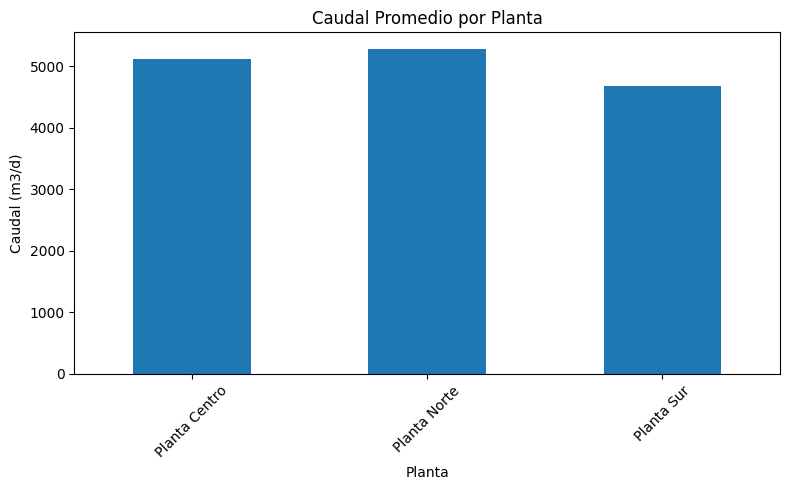

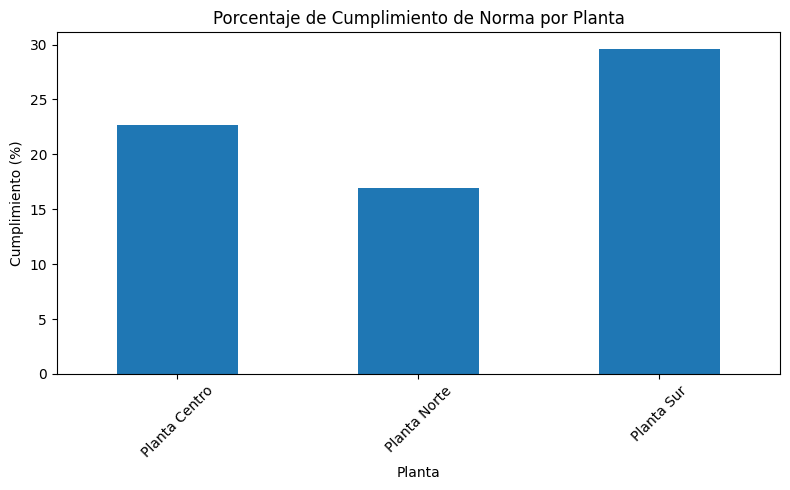

 Resultados exportados en carpeta /output

--- Indicadores generales ---
{'promedio_eficiencia': np.float64(87.09290814394676), 'max_eficiencia': 93.4319526627219, 'min_eficiencia': 80.6923076923077, 'promedio_energia': np.float64(0.2478341078759714)}


In [27]:
# ==========================================
# AquaLimpia S.A.
# alumno  : Jorge Salas
# Fecha   : 25/05/2026
# Semana  : 8
# Carrera : Ingeniería en informática
# ==========================================

import pandas as pd
import numpy as np
import os
import sys
import plotly.express as px
from plotly.subplots import make_subplots
from joblib import dump


BASE_DIR = os.getcwd()
scripts_path = os.path.join(BASE_DIR, "scripts")
sys.path.append(scripts_path)


# importar funciones de graficos de barra y validacion
from graficosdebarra import grafico_caudal_promedio, grafico_cumplimiento
from validaciones import validar_columnas, validar_valores_negativos, analizar_calidad_datos
columnas_requeridas = [
    "fecha_registro",
    "planta",
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "SST_entrada_mg_L",
    "pH_entrada",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d",
    "DBO_salida_mg_L",
    "cumplimiento_norma"
]


# ------------------------------------------
# Cargar datos
# ------------------------------------------

df_global = None

def cargar_datos():
    global df_global

    if df_global is not None:
        print("Datos ya cargados en memoria")
        return df_global

    ruta = os.path.join(BASE_DIR, "data", "dataset_set_A_aguas_residuales.xlsx")

    print("Buscando archivo en:", ruta)


    if os.path.exists(ruta):
        print("Archivo encontrado, cargando...")
        df = pd.read_excel(ruta)

    else:
        print("Archivo no encontrado, suba el dataset")

        from google.colab import files
        uploaded = files.upload()

        nombre = list(uploaded.keys())[0]

        os.makedirs(os.path.join(BASE_DIR, "data"), exist_ok=True)

        ruta = os.path.join(BASE_DIR, "data", nombre)

        with open(ruta, "wb") as f:
            f.write(uploaded[nombre])

        df = pd.read_excel(ruta)

    df.columns = df.columns.str.strip()
    df_global = df

    return df




# ------------------------------------------
# Limpieza de datos
# ------------------------------------------
def limpiar_datos(df):
    print("\n ---- Limpieza de datos ----")

    df = df.drop_duplicates()
    columnas_numericas = [
        "caudal_entrada_m3_d",
        "DBO_entrada_mg_L",
        "DBO_salida_mg_L",
        "energia_aeracion_kWh",
        "lodos_generados_kg_d"
    ]

    for col in columnas_numericas:
        df[col] = df[col].fillna(df[col].mean())

    return df

# ------------------------------------------
# Guardar almacenamiento intermedio
# ------------------------------------------
def guardar_intermedio(df):
    ruta_intermedio = os.path.join(BASE_DIR, "data", "intermedio")
    os.makedirs(ruta_intermedio, exist_ok=True)

    archivo = os.path.join(ruta_intermedio, "datos_limpios.csv")

    df.to_csv(archivo, index=False)

    print("Datos intermedios guardados en:", archivo)



# ------------------------------------------
# 5. Cálculo de indicadores
# ------------------------------------------
def calcular_indicadores(df):
    print("\n ---- Calculo indicadores ----")

    df["eficiencia_tratamiento"] = (
        (df["DBO_entrada_mg_L"] - df["DBO_salida_mg_L"]) /
        df["DBO_entrada_mg_L"]
    ) * 100

    df["energia_por_caudal"] = (
        df["energia_aeracion_kWh"] / df["caudal_entrada_m3_d"]
    )

    indicadores = {
        "promedio_eficiencia": np.mean(df["eficiencia_tratamiento"]),
        "max_eficiencia": np.max(df["eficiencia_tratamiento"]),
        "min_eficiencia": np.min(df["eficiencia_tratamiento"]),
        "promedio_energia": np.mean(df["energia_por_caudal"])
    }

    return df, indicadores




# ------------------------------------------
# 6. Agrupación por planta
# ------------------------------------------
def resumen_por_planta(df):
    resumen = df.groupby("planta").agg({
        "caudal_entrada_m3_d": "mean",
        "DBO_salida_mg_L": "mean",
        "eficiencia_tratamiento": "mean",
        "energia_aeracion_kWh": "mean",
        "lodos_generados_kg_d": "mean"
    }).reset_index()

    return resumen


# ------------------------------------------
# 7. Dashboard exploratorio
# ------------------------------------------
def dashboard_exploratorio(df):

    import plotly.express as px
    from plotly.subplots import make_subplots

    colores = {
        "principal": "#1f3b4d",   # azul oscuro
        "secundario": "#5fa8d3",  # azul claro
        "exito": "#2ca02c",       # verde
        "alerta": "#d62728",      # rojo
        "neutral": "#7f7f7f"      # gris
    }

    #Grafico 1 Caudal promedio por planta
    df_caudal = df.groupby("planta")["caudal_entrada_m3_d"].mean().reset_index()

    fig1 = px.bar(
        df_caudal,
        x="planta",
        y="caudal_entrada_m3_d",
        color="planta",
        color_discrete_sequence=[colores["secundario"]],
        title="1. Caudal Promedio por Planta"
    )

    #Grafico 2 % cumplimiento
    df_cumplimiento = df.groupby("planta")["cumplimiento_norma"].mean().reset_index()

    fig2 = px.bar(
        df_cumplimiento,
        x="planta",
        y="cumplimiento_norma",
        color="cumplimiento_norma",
        color_continuous_scale=["#d62728", "#ffbf00", "#2ca02c"],  # rojo → amarillo → verde
        title="2. % Cumplimiento Norma"
    )

    #Grafico 3 Boxplot eficiencia
    fig3 = px.box(
        df,
        x="planta",
        y="eficiencia_tratamiento",
        color="planta",
        color_discrete_sequence=[
            colores["principal"],
            colores["secundario"],
            "#8ecae6"
        ],
        title="3. Eficiencia de Tratamiento"
    )

    #Grafico 4 Scatter energía vs caudal
    fig4 = px.scatter(
        df,
        x="caudal_entrada_m3_d",
        y="energia_aeracion_kWh",
        color="planta",
        size="lodos_generados_kg_d",
        color_discrete_sequence=[
            colores["principal"],
            colores["secundario"],
            "#8ecae6"
        ],
        title="4. Energía vs Caudal"
    )

    # Layout tipo dashboard
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "Caudal Promedio",
            "% Cumplimiento",
            "Eficiencia",
            "Energía vs Caudal"
        )
    )

    for trace in fig1.data:
        fig.add_trace(trace, row=1, col=1)

    for trace in fig2.data:
        fig.add_trace(trace, row=1, col=2)

    for trace in fig3.data:
        fig.add_trace(trace, row=2, col=1)

    for trace in fig4.data:
        fig.add_trace(trace, row=2, col=2)

    #Estilo
    fig.update_layout(
        height=800,
        title={
            "text": "Dashboard Operacional - Plantas de Tratamiento",
            "x": 0.5,
            "xanchor": "center",
            "font": {"size": 20, "color": colores["principal"]}
        },
        plot_bgcolor="white",
        paper_bgcolor="white",
     legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.2,
        xanchor="center",
        x=0.5
    ),

    margin=dict(
        t=100,
        r=120,
        b=100
    )
    )
    fig.update_xaxes(showgrid=True, gridcolor="#e6e6e6")
    fig.update_yaxes(showgrid=True, gridcolor="#e6e6e6")

    fig.show()

    return fig


# ------------------------------------------
# 8. Exportar resultados
# ------------------------------------------
def exportar_resultados(df, resumen, indicadores, fig):

    os.makedirs("output", exist_ok=True)

    # Exportar datos
    df.to_csv("output/datos_procesados.csv", index=False)
    resumen.to_excel("output/resumen_planta.xlsx", index=False)

    # Exportar dashboard
    fig.write_html("output/dashboard.html")

    # Exportar indicadores
    with open("output/indicadores.txt", "w") as f:
        for k, v in indicadores.items():
            f.write(f"{k}: {v}\n")

    print(" Resultados exportados en carpeta /output")


# ------------------------------------------
# 8. Ejecución principal
# ------------------------------------------
def main():
    df = cargar_datos()

  # ejecuta desde validaciones.py
    validar_columnas(df, columnas_requeridas)
    validar_valores_negativos(df, [
        "caudal_entrada_m3_d",
        "DBO_entrada_mg_L",
        "DBO_salida_mg_L",
        "energia_aeracion_kWh",
        "lodos_generados_kg_d"
    ])

    analizar_calidad_datos(df)

    df = limpiar_datos(df)

    guardar_intermedio(df)

    df, indicadores = calcular_indicadores(df)

    resumen = resumen_por_planta(df)

    fig_dashboard = dashboard_exploratorio(df)

    # ejecuta desde graficosdebarra.py
    fig_bar1 = grafico_caudal_promedio(df)
    fig_bar2 = grafico_cumplimiento(df)

    exportar_resultados(df, resumen, indicadores, fig_dashboard)

    print("\n--- Indicadores generales ---")
    print(indicadores)


# ------------------------------------------
# Ejecutar script
# ------------------------------------------
if __name__ == "__main__":
    main()


Markdown.
# 📊 Análisis de Desempeño: Plantas de Tratamiento AquaLimpia S.A.

---

## 🎯 1. Objetivo del Proyecto
El objetivo del proyecto es analizar el desempeño operacional de las plantas de tratamiento de aguas residuales de **AquaLimpia S.A.** con el fin de evaluar:
* La **eficiencia** del proceso de depuración.
* El grado de **cumplimiento normativo** ambiental.
* El comportamiento del **consumo energético**.

---

## 💾 2. Fuente de Datos
la fuente de dartos es el archivo Excel `dataset_set_A_aguas_residuales.xlsx`, y contiene datos operacionales de las plantas en las siguientes columnas:

> * **Identificación de planta:** Nombre de la planta.
> * **Caudal de entrada:** Volumen de agua ingresado ($m^3/\text{día}$).
> * **DBO de entrada y salida:** Demanda Bioquímica de Oxígeno ($mg/L$).
> * **Energía de aireación:** Consumo energético ($kWh$).
> * **Lodos generados:** Subproductos del proceso ($kg/\text{día}$).
> * **Cumplimiento de norma:** Norma ambiental (1 = Cumple / 0 = No cumple).

---

## ⚙️ 3. Proceso Analítico (Workflow)
El desarrollo del análisis en este Notebook se divide en las siguientes etapas:

1.  **Importación de Datos:** Carga del archivo Excel al entorno de ejecución de Google Colab utilizando la librería `pandas`.
2.  **Evaluación de Calidad:** Identificar y eliminar valores nulos, registros duplicados o inconsistencias.
3.  **Limpieza y Preparación:** Estandarización de nombres de columnas y completar datos faltantes.
4.  **Métricas:** Cálculo de indicadores de negocio adicionales:
    * *Eficiencia del tratamiento* ($\%$ de remoción de DBO).
    * *Consumo energético específico* ($kWh/m^3$).
    * *Indicadores globales de cumplimiento*.
5.  **Agrupación:** Agrupación de datos por planta.
6.  **Visualización (Dashboard):** Construcción de gráficos interactivos utilizando `matplotlib` y `seaborn`:
    * Caudal promedio por instalación.
    * Tasa porcentual de cumplimiento de norma.
    * Distribución de la eficiencia del tratamiento.
    * Dispersión y relación matemática entre *Energía* vs *Caudal*.

---

## 📈 4. Resultados Clave
el análisis del dashboard, identifico los siguientes hallazgos:
* **Variabilidad en Eficiencia:** •	Se aprecian diferencias de eficiencia entre las plantas.
* **Alertas de Cumplimiento:** •	hay plantas con bajo cumplimiento normativo.
* **Comportamiento Energético:** •	El consumo de energía varía según el caudal.
* **Optimización:** Se aprecia oportunidades de mejora en los procesos.

---

## 💡 5. Conclusiones
el análisis permite detectar problemas normativos y de desempeño de las plantas, con la información obtenida se puede elaborar un **plan de mejora** para cumplir con las normativas ambientales y mejorar la eficiencia.

---

## 🔄 6. Reproducibilidad y Gobierno de Código
Con el fin de garantizar que este análisis pueda ser auditado o automatizado en el futuro:
* La lógica de código se encapsuló en **funciones de Python modulares**.
* El control de versiones y el almacenamiento de los scripts se gestiona a través de un **repositorio en GitHub**.
